# Dermoscopy Practicum (Stages 1–3): Pillow (PIL), NumPy, Matplotlib

- **Stage 1:** Pillow (PIL) for image I/O and simple conversions
- **Stage 2:** NumPy for image-as-array thinking (shape, dtype, slicing)
- **Stage 3:** Matplotlib for correct display and simple grids

You will load random ISIC images from:

```python
ROOT = Path("..")
ISIC_DIR = ROOT / "data" / "isic2018"
ISIC_IMG_DIR  = ISIC_DIR / "images"
ISIC_MASK_DIR = ISIC_DIR / "masks"
```

The aim is not to build a pipeline; it is to learn what each library does and what assumptions it makes.

## 0. Setup: imports and dataset paths

In [ ]:
from __future__ import annotations

from pathlib import Path
import random

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Paths - ISIC
ROOT = Path("..")
ISIC_DIR = ROOT / "data" / "isic2018"
ISIC_IMG_DIR  = ISIC_DIR / "images"
ISIC_MASK_DIR = ISIC_DIR / "masks"

print("ROOT:", ROOT.resolve())
print("ISIC_IMG_DIR:", ISIC_IMG_DIR.resolve())
print("ISIC_MASK_DIR:", ISIC_MASK_DIR.resolve())
print("Images dir exists:", ISIC_IMG_DIR.exists())
print("Masks dir exists:", ISIC_MASK_DIR.exists())

# Paths - HAM
HAM_DIR = ROOT / "data" / "ham10000"
HAM_IMG_DIR  = HAM_DIR / "images"
HAM_MASK_DIR = HAM_DIR / "masks"

print("ROOT:", ROOT.resolve())
print("HAM_IMG_DIR:", HAM_IMG_DIR.resolve())
print("HAM_MASK_DIR:", HAM_MASK_DIR.resolve())
print("Images dir exists:", HAM_IMG_DIR.exists())
print("Masks dir exists:", HAM_MASK_DIR.exists())

ROOT: /home/jessica/Projects/DCU/2026-mcm-XAI-skin-lesion
ISIC_IMG_DIR: /home/jessica/Projects/DCU/2026-mcm-XAI-skin-lesion/data/isic2018/images
ISIC_MASK_DIR: /home/jessica/Projects/DCU/2026-mcm-XAI-skin-lesion/data/isic2018/masks
Images dir exists: True
Masks dir exists: True
ROOT: /home/jessica/Projects/DCU/2026-mcm-XAI-skin-lesion
HAM_IMG_DIR: /home/jessica/Projects/DCU/2026-mcm-XAI-skin-lesion/data/ham10000/images
HAM_MASK_DIR: /home/jessica/Projects/DCU/2026-mcm-XAI-skin-lesion/data/ham10000/masks
Images dir exists: True
Masks dir exists: True


## 0.1 Collect image paths and pick a random sample

In [3]:
# Collect common image extensions
exts = ["*.jpg", "*.jpeg", "*.png"]
img_paths: list[Path] = []
for ext in exts:
    img_paths.extend(list(HAM_IMG_DIR.glob(ext)))

img_paths = sorted(img_paths)
assert img_paths, f"No images found in {HAM_IMG_DIR}. Check your paths and file extensions."

print("Number of images found:", len(img_paths))
print("First 5:", [p.name for p in img_paths[:5]])

# Reproducible randomness for learning (change the seed to change the sample)
random.seed(0)

N = 8 
sample_paths = random.sample(img_paths, k=min(N, len(img_paths)))
sample_paths

Number of images found: 10015
First 5: ['ISIC_0024306.jpg', 'ISIC_0024307.jpg', 'ISIC_0024308.jpg', 'ISIC_0024309.jpg', 'ISIC_0024310.jpg']


[PosixPath('../data/ham10000/images/ISIC_0030617.jpg'),
 PosixPath('../data/ham10000/images/ISIC_0031196.jpg'),
 PosixPath('../data/ham10000/images/ISIC_0024969.jpg'),
 PosixPath('../data/ham10000/images/ISIC_0028548.jpg'),
 PosixPath('../data/ham10000/images/ISIC_0032682.jpg'),
 PosixPath('../data/ham10000/images/ISIC_0032267.jpg'),
 PosixPath('../data/ham10000/images/ISIC_0030940.jpg'),
 PosixPath('../data/ham10000/images/ISIC_0029275.jpg')]

# Stage 1: Pillow (PIL): Image I/O and basic conversions

## Objectives
- Open an image from disk with `Image.open`
- Inspect **mode** (`RGB`, `L`, etc.) and **size**
- Convert modes using `convert("RGB")` and `convert("L")`
- Save an image back to disk

**Key idea:** PIL objects are not NumPy arrays. PIL is great for I/O and basic operations, but most ML work happens on arrays.

## 1.1 Open one random image and inspect it (PIL object)

File: ISIC_0030617.jpg
PIL type: <class 'PIL.JpegImagePlugin.JpegImageFile'>
Mode: RGB
Size (W, H): (600, 450)


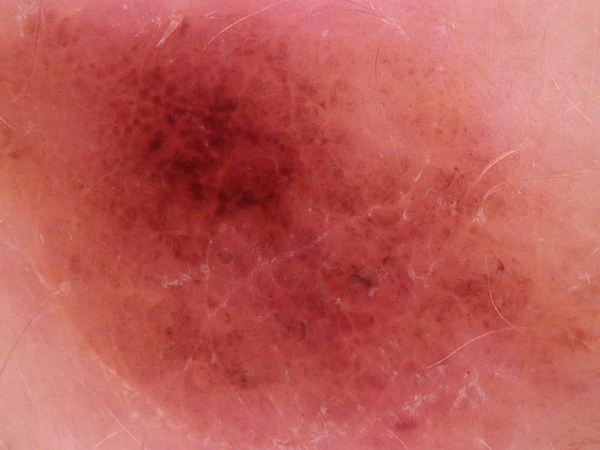

In [4]:
img_path = sample_paths[0]
pil_img = Image.open(img_path)

print("File:", img_path.name)
print("PIL type:", type(pil_img))
print("Mode:", pil_img.mode)  # e.g. 'RGB'
print("Size (W, H):", pil_img.size)
pil_img

## 1.2 Convert modes

- `RGB` is 3 channels (Red, Green, Blue)
- `L` is 1 channel grayscale

You should expect:
- `RGB` image array shape: `(H, W, 3)`
- `L` image array shape: `(H, W)`

RGB mode: RGB | size: (600, 450)
Gray mode: L | size: (600, 450)


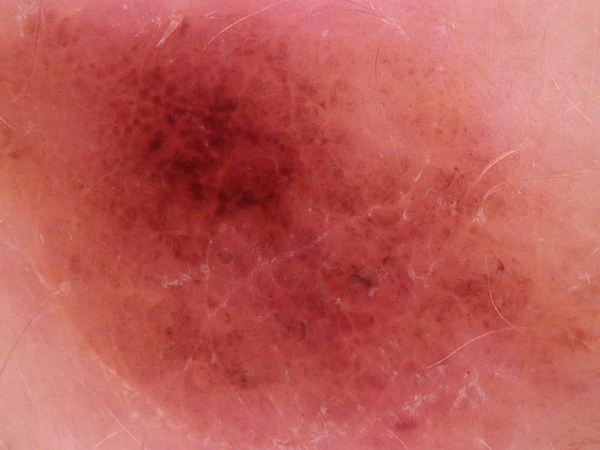

In [5]:
pil_rgb = pil_img.convert("RGB")
pil_gray = pil_img.convert("L")

print("RGB mode:", pil_rgb.mode, "| size:", pil_rgb.size)
print("Gray mode:", pil_gray.mode, "| size:", pil_gray.size)

# Display inline (Jupyter shows PIL images nicely)
pil_rgb

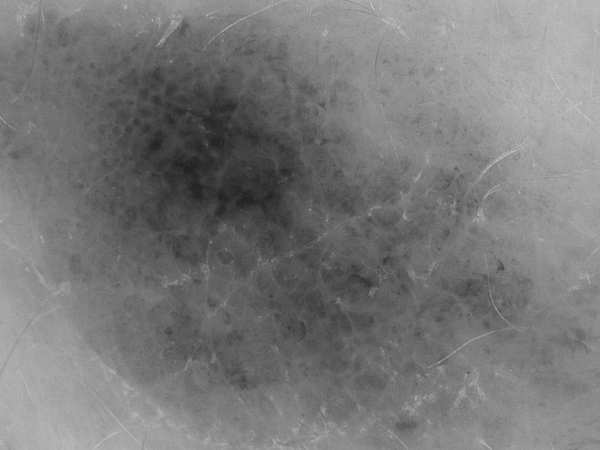

In [6]:
pil_gray

## 1.3 Save a converted copy

This creates an `outputs_stage1` folder under your notebook folder (not inside `..`), so you do not modify the dataset.

In [7]:
# Run this cell to save the images -  delete afterwards to avoid putting too much data in git
''' OUT_DIR = Path("outputs_stage1")
OUT_DIR.mkdir(parents=True, exist_ok=True)

out_rgb_path = OUT_DIR / f"{img_path.stem}_rgb.png"
out_gray_path = OUT_DIR / f"{img_path.stem}_gray.png"

pil_rgb.save(out_rgb_path)
pil_gray.save(out_gray_path)

print("Saved:", out_rgb_path)
print("Saved:", out_gray_path)
'''

' OUT_DIR = Path("outputs_stage1")\nOUT_DIR.mkdir(parents=True, exist_ok=True)\n\nout_rgb_path = OUT_DIR / f"{img_path.stem}_rgb.png"\nout_gray_path = OUT_DIR / f"{img_path.stem}_gray.png"\n\npil_rgb.save(out_rgb_path)\npil_gray.save(out_gray_path)\n\nprint("Saved:", out_rgb_path)\nprint("Saved:", out_gray_path)\n'

# Stage 2 — NumPy: Images as arrays

## Objectives
- Convert PIL → NumPy (`np.array(...)`)
- Inspect shape, dtype, min/max
- Learn slicing for crops and channels

**Key idea:** Most image processing and ML models operate on arrays.

## 2.1 Convert to NumPy and inspect

In [8]:
img_rgb_u8 = np.array(pil_rgb)   # usually uint8
img_gray_u8 = np.array(pil_gray)  # usually uint8

print("RGB array shape (H, W, C):", img_rgb_u8.shape)
print("RGB dtype:", img_rgb_u8.dtype, "| min/max:", img_rgb_u8.min(), img_rgb_u8.max())
print()
print("Gray array shape (H, W):", img_gray_u8.shape)
print("Gray dtype:", img_gray_u8.dtype, "| min/max:", img_gray_u8.min(), img_gray_u8.max())

RGB array shape (H, W, C): (450, 600, 3)
RGB dtype: uint8 | min/max: 2 255

Gray array shape (H, W): (450, 600)
Gray dtype: uint8 | min/max: 30 205


## 2.2 Channels and slicing

In an RGB array:
- `img[..., 0]` is the red channel
- `img[..., 1]` is green
- `img[..., 2]` is blue

In a grayscale array, there is no channel axis.

In [9]:
red = img_rgb_u8[..., 0]
green = img_rgb_u8[..., 1]
blue = img_rgb_u8[..., 2]

print("Red channel shape:", red.shape, red.dtype)
print("Green channel shape:", green.shape, green.dtype)
print("Blue channel shape:", blue.shape, blue.dtype)

Red channel shape: (450, 600) uint8
Green channel shape: (450, 600) uint8
Blue channel shape: (450, 600) uint8


## 2.3 Centre crop with slicing

This is the simplest form of cropping: selecting a rectangle with array indices.

Reminder: shape is `(H, W, C)` so you slice as:
- rows (y): `y0:y1`
- cols (x): `x0:x1`

In [10]:
H, W = img_rgb_u8.shape[:2]
crop_size = min(H, W, 500)

y0 = (H - crop_size) // 2
x0 = (W - crop_size) // 2

crop_center_rgb = img_rgb_u8[y0:y0+crop_size, x0:x0+crop_size]
crop_center_gray = img_gray_u8[y0:y0+crop_size, x0:x0+crop_size]

print("Original RGB:", img_rgb_u8.shape, "| Cropped RGB:", crop_center_rgb.shape)
print("Original gray:", img_gray_u8.shape, "| Cropped gray:", crop_center_gray.shape)

Original RGB: (450, 600, 3) | Cropped RGB: (450, 450, 3)
Original gray: (450, 600) | Cropped gray: (450, 450)


## 2.4 Exercise (recommended)

Try changing these and observe what happens:
- `crop_size`
- cropping from the top-left corner instead of the centre
- extracting only the lesion area if you visually identify it (manual crop)

You will use this intuition later when working with masks.

In [11]:
# Cropping from the top-left corner instead of the centre
crop_size = min(H, W, 500)
crop_0_rgb = img_rgb_u8[0:crop_size, 0:crop_size]
crop_0_gray = img_gray_u8[0:crop_size, 0:crop_size]

In [13]:
# Cropping rectangle around the lesion (from mask)

# Function to find the mask
def find_mask_for_image(mask_dir: Path, img_path: Path) -> Path | None:
    # Common HAM naming: same stem with _segmentation.png
    direct = mask_dir / f"{img_path.stem}_segmentation.png"
    return direct

# Function to load grayscale image as numpy array
def load_gray(path: Path) -> np.ndarray:
    return np.array(Image.open(path).convert("L"))

# Function to binarise mask
def binarise_mask(mask_gray: np.ndarray) -> np.ndarray:
    return (mask_gray > 0).astype(np.uint8)

mask_path = find_mask_for_image(HAM_MASK_DIR, img_path)
print(mask_path)

img_mask_bin = binarise_mask(load_gray(mask_path))

# Find lesion pixels (True locations)
ys, xs = np.where(img_mask_bin)

if len(xs) == 0:
    raise ValueError("Mask is empty (no lesion pixels).")

y0, y1 = ys.min(), ys.max() + 1
x0, x1 = xs.min(), xs.max() + 1

lesion_crop = img_rgb_u8[y0:y1, x0:x1]
mask_crop   = img_mask_bin[y0:y1, x0:x1]

../data/ham10000/masks/ISIC_0030617_segmentation.png


# Stage 3 — Matplotlib: correct display

## Objectives
- Display arrays with `plt.imshow`
- Use `cmap="gray"` for grayscale
- Make side-by-side plots with `plt.subplot`
- Build a small grid of random images

**Key idea:** Matplotlib shows what you give it. It will not “fix” dtype or scaling mistakes.

## 3.1 Display RGB and grayscale correctly

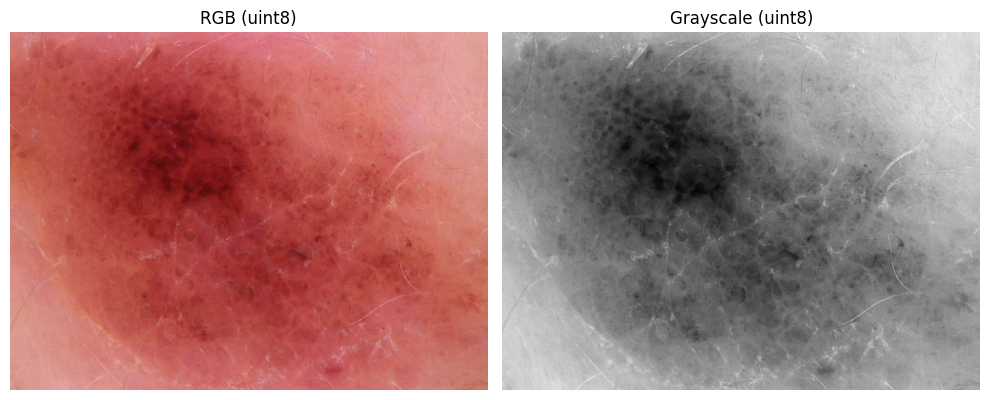

In [14]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(lesion_crop)
plt.title("RGB (uint8)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_gray_u8, cmap="gray")
plt.title("Grayscale (uint8)")
plt.axis("off")

plt.tight_layout()
plt.show()

## 3.2 Display the red/green/blue channels

This is useful in dermoscopy because lesions often have meaningful differences by channel (especially redness/erythema).

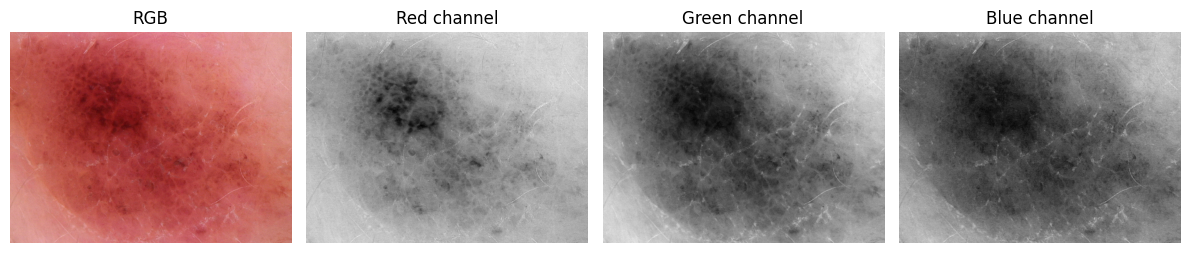

In [15]:
plt.figure(figsize=(12, 3))

plt.subplot(1, 4, 1)
plt.imshow(img_rgb_u8)
plt.title("RGB")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(red, cmap="gray")
plt.title("Red channel")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(green, cmap="gray")
plt.title("Green channel")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(blue, cmap="gray")
plt.title("Blue channel")
plt.axis("off")

plt.tight_layout()
plt.show()

## 3.3 A grid of random images (quick dataset sanity check)

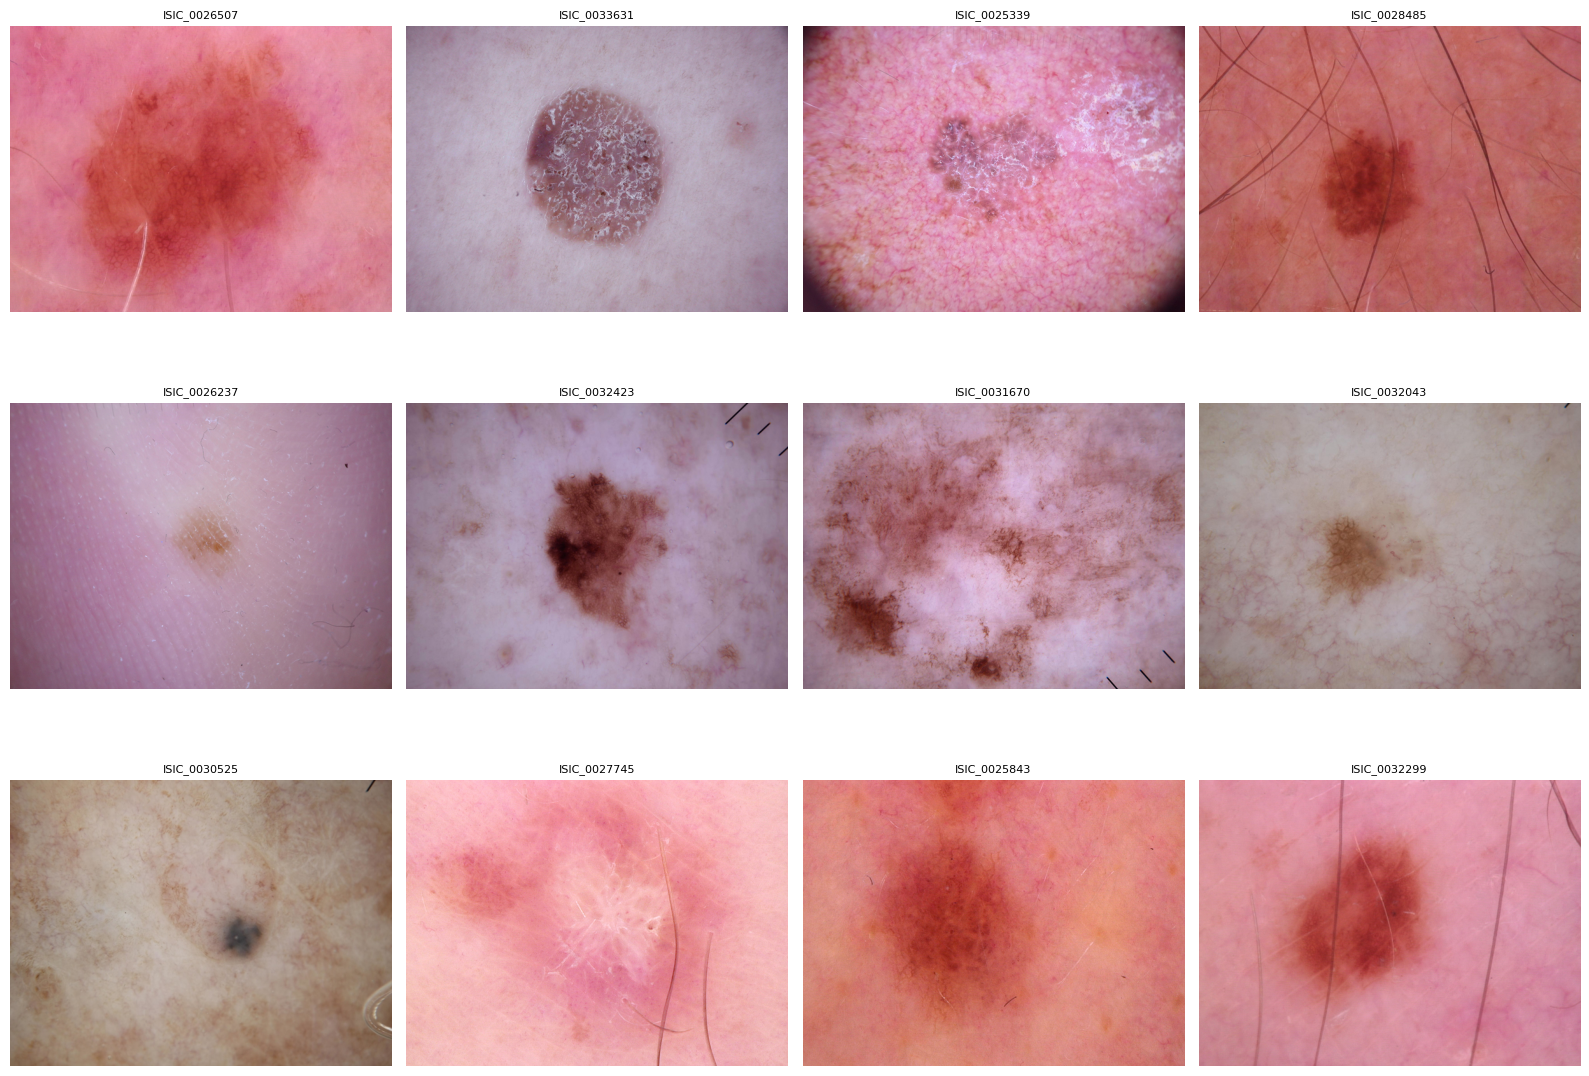

In [16]:
def load_rgb_u8(path: Path) -> np.ndarray:
    """Load as RGB uint8 array."""
    with Image.open(path) as im:
        return np.array(im.convert("RGB"), dtype=np.uint8)


# Pick a fresh random sample
random.seed(1)
K = 12
grid_paths = random.sample(img_paths, k=min(K, len(img_paths)))

cols = 4
rows = int(np.ceil(len(grid_paths) / cols))
plt.figure(figsize=(4 * cols, 4 * rows))

for i, p in enumerate(grid_paths, start=1):
    img = load_rgb_u8(p)
    plt.subplot(rows, cols, i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(p.stem, fontsize=8)

plt.tight_layout()
plt.show()